# Pima Indians Diabetes

Dataset-specific starting notebook for the DataFrameSampler paper experiments.

Claim-specific role: small medical classification benchmark with missing clinical measurements, useful for testing medical-style mixed-schema workflows.


## Setup

Run the downloader before executing this notebook:

```bash
python experiments/download_datasets.py
```

Dataset-specific choices live in `experiments/datasets.py`; the reusable execution path lives in `experiments/workflow.py`.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.exploration import column_distribution_summary, plot_column_distributions, plot_pairwise_features
import experiments.numeric_projection as numeric_projection
importlib.reload(numeric_projection)
from experiments.numeric_projection import numeric_view_from_config, plot_numeric_projection_triptych
from experiments.manifold_validation import summarize_manifold_validation
from experiments.mechanism_validation import summarize_decoder_calibration, summarize_mechanism_validation
from experiments.predictive import predictive_performance_report, target_column_choice
from experiments.workflow import dataset_profile, experiment_paths, load_dataset, notebook_environment, run_configured_dataset_experiment, working_dataframe
from experiments.vectorization_plan import preprocessing_plan, vectorization_plan

DATASET_NAME = "pima_diabetes"
CONFIG = DATASET_CONFIGS[DATASET_NAME]
PATHS = experiment_paths(CONFIG, root=ROOT)
notebook_environment(PATHS)


{'python': '3.11.13',
 'pandas': '2.3.3',
 'dataset': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/pima_diabetes.csv'}

## Load Prepared Data

Exploration uses the prepared source dataframe before the experiment workflow fits or samples anything.


In [2]:
dataframe = load_dataset(CONFIG, root=ROOT)
work = working_dataframe(dataframe, CONFIG)
profile = dataset_profile(dataframe)
dataframe.shape, dataframe.head()


((768, 9),
    pregnancies  glucose  blood_pressure  skin_thickness  insulin   bmi  \
 0            6    148.0            72.0            35.0      NaN  33.6   
 1            1     85.0            66.0            29.0      NaN  26.6   
 2            8    183.0            64.0             NaN      NaN  23.3   
 3            1     89.0            66.0            23.0     94.0  28.1   
 4            0    137.0            40.0            35.0    168.0  43.1   
 
    diabetes_pedigree  age  diabetes  
 0              0.627   50  positive  
 1              0.351   31  negative  
 2              0.672   32  positive  
 3              0.167   21  negative  
 4              2.288   33  positive  )

## Target Column Choice

The predictive task uses this target column from the prepared dataframe.

In [3]:
target_column_choice(CONFIG, dataframe)


,target_column,task,available,unique,missing,note
0,diabetes,classification,True,2,0,Configured in experiments/datasets.py and used...


## Dataset Profile

The reusable Pima diabetes configuration runs on the full prepared table. Zero-valued clinical measurements that conventionally represent missing values are converted to missing values during preparation.


In [4]:
profile


,dtype,missing,unique
pregnancies,int64,0,17
glucose,float64,5,135
blood_pressure,float64,35,46
skin_thickness,float64,227,50
insulin,float64,374,185
bmi,float64,11,247
diabetes_pedigree,float64,0,517
age,int64,0,52
diabetes,object,0,2


## Column Vectorization Plan

These are the columns that require vectorization before latent learning. The table records whether each column is numeric, directly mapped, discarded as high-cardinality, binary categorical, or NCA latent encoded to one numeric coordinate.


In [5]:
pre_plan = preprocessing_plan(CONFIG)
if not pre_plan.empty:
    display(pre_plan)

vector_plan = vectorization_plan(dataframe, CONFIG)
vector_plan[vector_plan["strategy"] == "categorical_nca"][
    ["column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,column,strategy,latent_components,high_cardinality_warning,rationale
8,diabetes,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


## Exploratory Data Analysis

These cells run before `run_configured_dataset_experiment`. They summarize every column, plot per-column distributions on the human-readable dataframe, and show pairwise feature relationships after the configured sampler has reduced the working sample to numeric coordinates.


In [6]:
column_distribution_summary(dataframe)


,column,dtype,missing_rate,unique,kind,mean,std,min,median,max,top_values
0,pregnancies,int64,0.000000,17,numeric,3.845052,3.369578,0,3.0,17,
1,glucose,float64,0.006510,135,numeric,121.686763,30.535641,44.0,117.0,199.0,
2,blood_pressure,float64,0.045573,46,numeric,72.405184,12.382158,24.0,72.0,122.0,
3,skin_thickness,float64,0.295573,50,numeric,29.15342,10.476982,7.0,29.0,99.0,
4,insulin,float64,0.486979,185,numeric,155.548223,118.775855,14.0,125.0,846.0,
5,bmi,float64,0.014323,247,numeric,32.457464,6.924988,18.2,32.3,67.1,
6,diabetes_pedigree,float64,0.000000,517,numeric,0.471876,0.331329,0.078,0.3725,2.42,
7,age,int64,0.000000,52,numeric,33.240885,11.760232,21,29.0,81,
8,diabetes,object,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,negative: 0.65; positive: 0.35


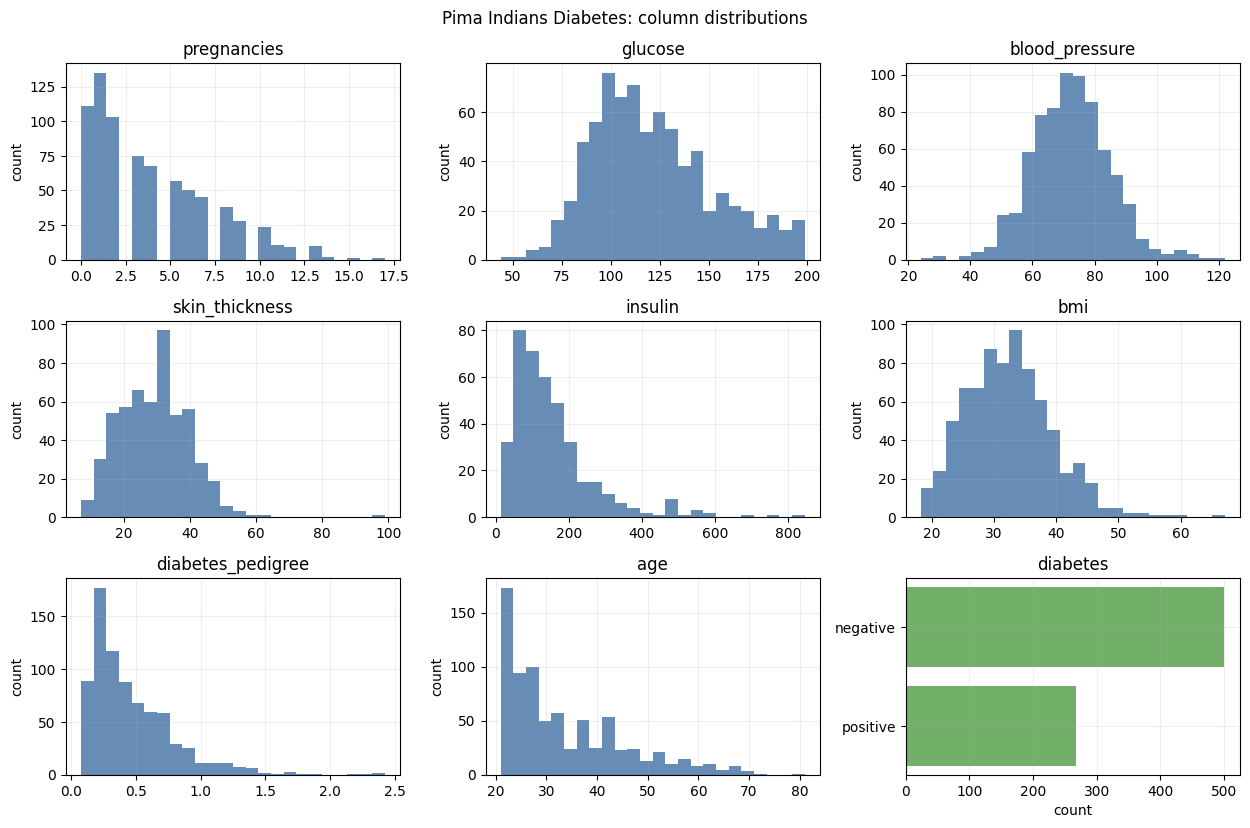

In [7]:
_ = plot_column_distributions(dataframe, title="Pima Indians Diabetes")

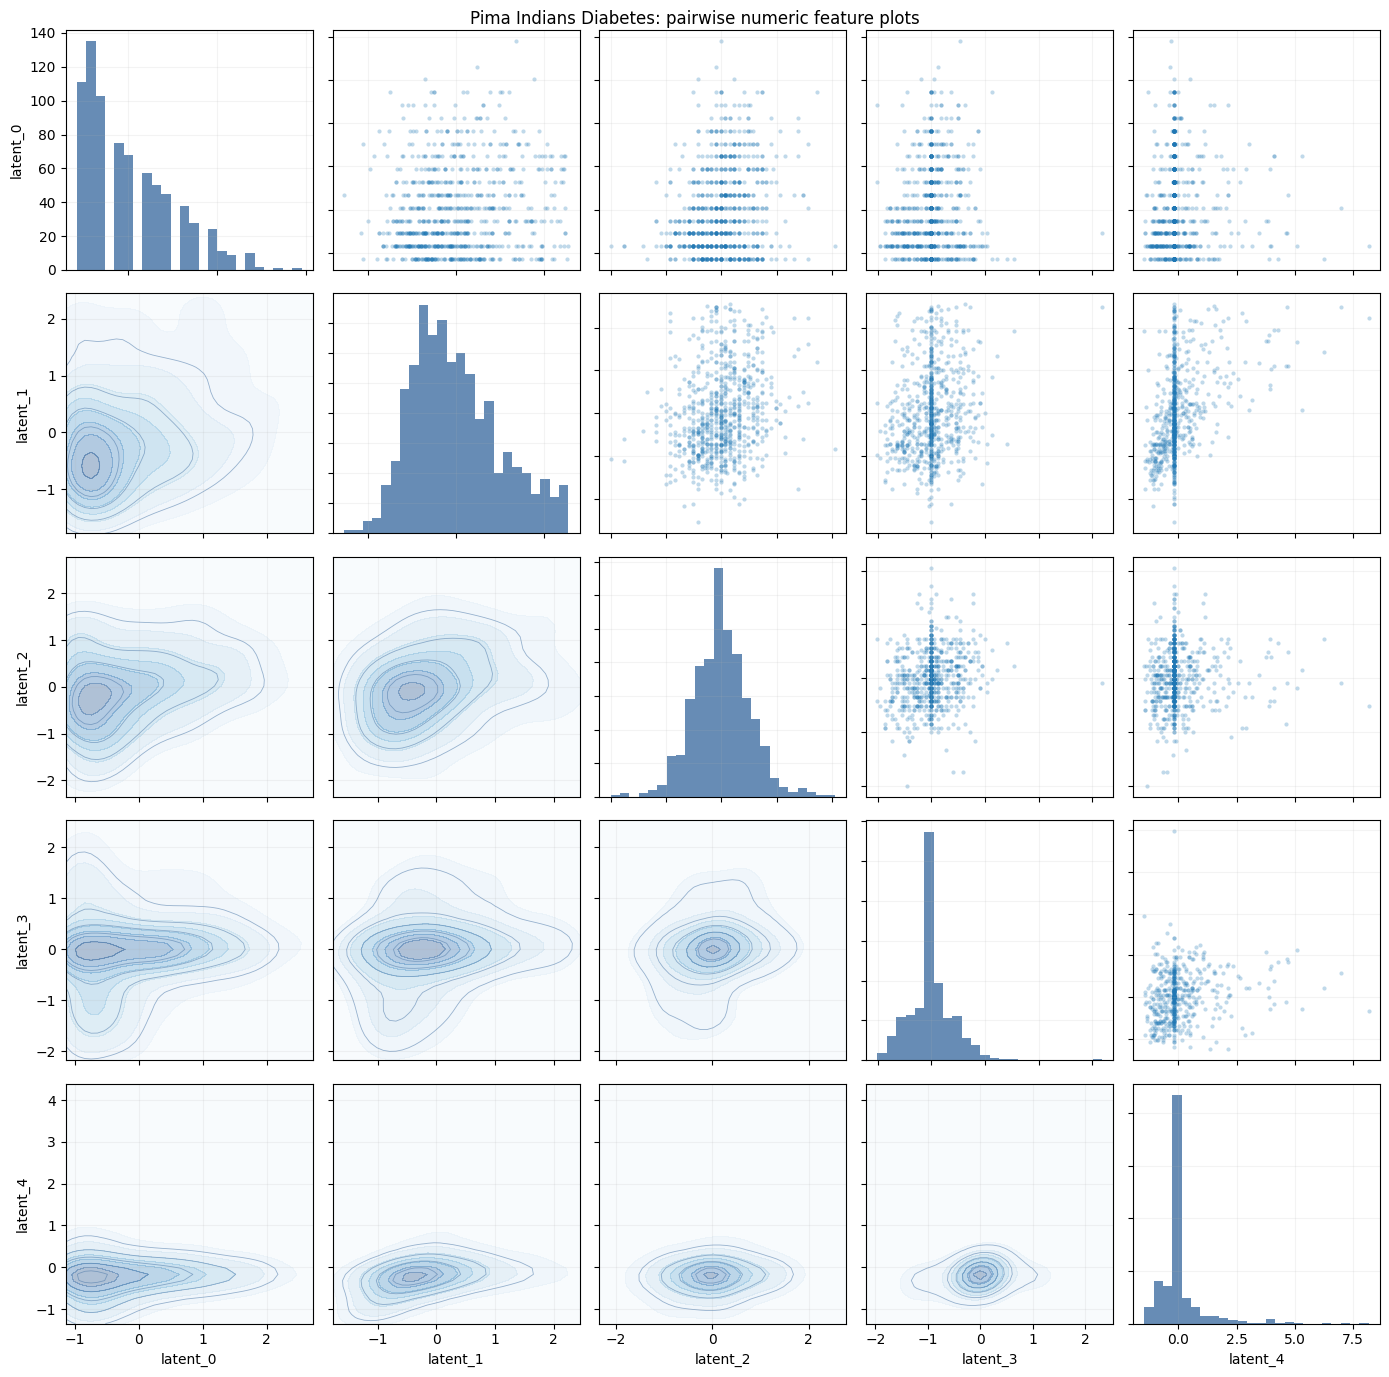

In [8]:
numeric_work = numeric_view_from_config(work, CONFIG)
_ = plot_pairwise_features(numeric_work, target_column=CONFIG.target_column, title="Pima Indians Diabetes")

## Run Experiment

The full sampler/baseline workflow runs after the exploratory cells.


In [9]:
result = run_configured_dataset_experiment(CONFIG, root=ROOT)
result.paths


ExperimentPaths(root=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler'), data_path=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/pima_diabetes.csv'), results_dir=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/results'))

## Starter DataFrameSampler Run

The workflow writes the generated starter sample, quick similarity report, and runtime row to `experiments/results/`.


In [10]:
result.starter_run.fit_seconds, result.starter_run.sample_seconds, result.starter_run.generated.head()


(25.340817752992734,
 2.5202121310285293,
    pregnancies  glucose  blood_pressure  skin_thickness  insulin   bmi  \
 0            0    123.0            64.0            21.0    117.0  36.1   
 1            3    116.0            62.0            15.0     51.0  21.7   
 2            0    140.0            94.0            29.0    125.0  49.0   
 3            0    168.0            50.0            20.0    140.0  29.4   
 4           10    143.0            58.0            27.0    125.0  40.4   
 
    diabetes_pedigree  age  diabetes  
 0              0.102   30  positive  
 1              0.078   21  negative  
 2              0.078   34  positive  
 3              0.078   21  negative  
 4              0.261   40  positive  )

In [11]:
result.starter_run.similarity_report


,column,kind,real_mean,synthetic_mean,abs_mean_delta,real_missing,synthetic_missing,real_unique,synthetic_unique,category_coverage
0,pregnancies,numeric,3.845052,4.242188,0.397135,0.000000,0.0,NaN,NaN,NaN
1,glucose,numeric,121.686763,120.494792,1.191971,0.006510,0.0,NaN,NaN,NaN
2,blood_pressure,numeric,72.405184,71.977865,0.427320,0.045573,0.0,NaN,NaN,NaN
3,skin_thickness,numeric,29.153420,29.312500,0.159080,0.295573,0.0,NaN,NaN,NaN
4,insulin,numeric,155.548223,144.140625,11.407598,0.486979,0.0,NaN,NaN,NaN
5,bmi,numeric,32.457464,32.723047,0.265583,0.014323,0.0,NaN,NaN,NaN
6,diabetes_pedigree,numeric,0.471876,0.517522,0.045646,0.000000,0.0,NaN,NaN,NaN
7,age,numeric,33.240885,33.598958,0.358073,0.000000,0.0,NaN,NaN,NaN
8,diabetes,categorical,NaN,NaN,NaN,0.000000,0.0,2.0,2.0,1.0


## Numeric Projection Of Generated Data

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/figures/pima_diabetes_numeric_projection.pdf')

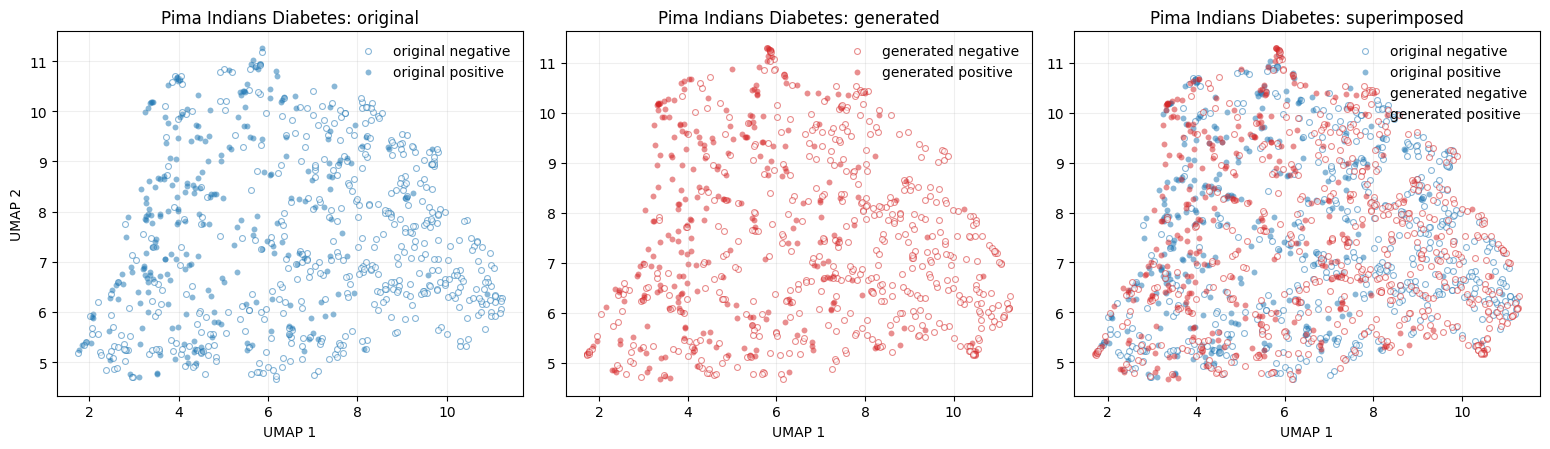

In [12]:
_ = plot_numeric_projection_triptych(
    result.starter_run.sampler,
    result.working_dataframe,
    result.starter_run.generated,
    target_column=CONFIG.target_column,
    title=CONFIG.title,
    reducer="umap",
    random_state=CONFIG.random_state,
)


## Baseline and Configuration Comparison

The same workflow runs DataFrameSampler default/manual configurations and the simple baselines, then writes the comparison CSV.


In [13]:
result.comparison


,dataset,method,n_real,n_synthetic,numeric_mean_abs_error,numeric_std_abs_error,numeric_ks_statistic,numeric_wasserstein_distance,numeric_histogram_overlap,categorical_total_variation,...,discrimination_privacy_score,utility_task,utility_real_score,utility_augmented_score,utility_lift,distribution_histogram_overlap,distribution_numeric_kl,distribution_categorical_jsd,distribution_categorical_tv,distribution_similarity_score
0,pima_diabetes,dataframe_sampler_default,768,768,1.350835,3.518220,0.115006,3.909075,0.827141,0.006510,...,0.429501,classification,0.714437,0.746551,0.032114,0.827141,0.122771,0.000034,0.006510,0.940199
1,pima_diabetes,dataframe_sampler_manual,768,768,1.781551,3.298104,0.115809,4.244315,0.817971,0.003906,...,0.416486,classification,0.714437,0.726027,0.011591,0.817971,0.126946,0.000012,0.003906,0.938018
2,pima_diabetes,gaussian_copula_empirical,768,768,2.534679,5.783855,0.042044,3.850951,0.935952,0.024740,...,0.906725,classification,0.714437,0.684254,-0.030182,0.935952,0.129088,0.000478,0.024740,0.970245
3,pima_diabetes,independent_columns,768,768,0.320328,0.840109,0.029557,1.044403,0.949901,0.026042,...,0.577007,classification,0.714437,0.741516,0.027080,0.949901,0.092157,0.000530,0.026042,0.974443
4,pima_diabetes,row_bootstrap,768,768,1.660686,1.695201,0.030588,1.977429,0.948127,0.022135,...,0.776573,classification,0.714437,0.877645,0.163209,0.948127,0.079572,0.000384,0.022135,0.975203
5,pima_diabetes,stratified_columns,768,768,0.473629,0.739049,0.030374,1.098338,0.946393,0.010417,...,0.715835,classification,0.714437,0.782234,0.067797,0.946393,0.067224,0.000087,0.010417,0.978630


In [14]:
summarize_manifold_validation(result.manifold_validation)


,dataset,method,out_hull_rate,real_stress_median,real_stress_q95,generated_stress_median,out_hull_stress_median,out_hull_acceptance_at_real_q95
0,pima_diabetes,dataframe_sampler_manual,0.92,0.016261,0.032163,0.015979,0.016019,0.982609
1,pima_diabetes,latent_interpolation,0.00,0.016261,0.032163,0.015846,NaN,NaN


In [ ]:
summarize_mechanism_validation(result.mechanism_validation)


In [ ]:
summarize_decoder_calibration(result.decoder_calibration)


## Predictive Target Evaluation

The real data is split into train/test rows. The sampler is fit only on the real training rows, then real train, real test, and synthetic-from-train rows are reduced to the sampler numeric view. The table compares a predictor trained on real training rows with one trained only on generated rows, both tested on the same real test rows.

In [15]:
predictive_report = predictive_performance_report(work, CONFIG)
predictive_report


,dataset,target_column,task,training_source,accuracy,balanced_accuracy,f1_weighted,roc_auc,mae,rmse,r2,train_rows,test_rows
0,pima_diabetes,diabetes,classification,real_train,0.718615,0.678272,0.714437,0.818683,NaN,NaN,NaN,537,231
1,pima_diabetes,diabetes,classification,synthetic_from_real_train,0.740260,0.680741,0.727294,0.812181,NaN,NaN,NaN,537,231
